# Appendix A 

Reproduce the figure 1a in LH2001 according to Appendix A
1. do Fourier transfomr of z and m
   
   $$Z(\omega) = \int z(t) e^{(i\omega t)} dt$$

   $$M(\omega) = \int m(t) e^{(i\omega t)} dt$$

2. By the eq.(2): ${dz \over dt} = m - {z \over \tau}$:
   Take eq.(2) Fourier transform and organize:

   $$ i\omega Z = M - {Z \over \tau} $$

   $$ (i\omega + {1 \over \tau})Z  = M $$

   $$\Rightarrow  ax = y \Rightarrow a =  {yx^* \over xx^*}$$

   $$ {Z^*M \over ZZ^*} = {1 \over \tau} + {i\omega}$$

In [214]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Load the time series
z = np.load("/work/prcpltwfkwd/z.npy")
m = np.load("/work/prcpltwfkwd/m.npy")

N = len(z)
dt = 1/4  # Time step in days

# Assuming 'z' is your 1D numpy array
segment_length = 256 * 4 # 256 day - 6hourly data
overlap = 128 * 4
step = segment_length - overlap  # This will be 512

# Slice the array into overlapping segments
segments_z = np.array([z[i : i + segment_length] for i in range(0, len(z) - segment_length + 1, step)])
segments_m = np.array([m[i : i + segment_length] for i in range(0, len(z) - segment_length + 1, step)])

In [197]:
# If you need to manually apply the Hanning window to these explicitly extracted segments:
hanning_window_z    = np.hanning(segment_length)
windowed_segments_z = segments_z * hanning_window_z

hanning_window_m    = np.hanning(segment_length)
windowed_segments_m = segments_m * hanning_window_m

# 1. Transform to spectral domain
num_segments = len(windowed_segments_z) # 130
segment_length = 1024

# Initialize as 2D arrays with complex data type
Z = np.zeros((num_segments, segment_length), dtype=complex)
M = np.zeros((num_segments, segment_length), dtype=complex)

# Assign the 1024-length FFT output to the entire row i
for i in range(num_segments):
    Z[i, :] = np.fft.fft(windowed_segments_z[i, :])
    M[i, :] = np.fft.fft(windowed_segments_m[i, :])

In [200]:
# Frequencies in cycles/day
freqs = np.fft.fftfreq(N, d=dt)

# Angular frequency (omega = 2 * pi * f)
omega = 2 * np.pi * freqs

In [201]:
# 2. Calculate the transfer function H = (Z * M*) / (Z * Z*)
cross_spec = np.conj(Z) * (M)
z_power = Z * np.conj(Z) #np.abs(Z)**2

# Ignore the zero-frequency (mean) component to avoid division by zero issues
H = cross_spec[:].mean(axis=0) / z_power[:].mean(axis=0)
# omega = omega[:]
# freqs = freqs[:]

Text(0.5, 1.0, 'Transfer function')

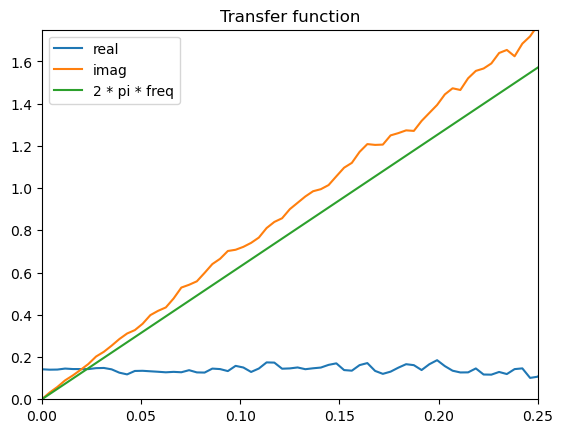

In [215]:
freqs_1024 = np.fft.fftfreq(segment_length, d=1/4)
freqs_1024_shift = np.fft.fftshift(freqs_1024)

plt.figure()
plt.plot(freqs_1024_shift, np.fft.fftshift(H.real), label="real")
plt.plot(freqs_1024_shift, np.fft.fftshift(H.imag), label="imag")
plt.plot(freqs_1024_shift, freqs_1024_shift * 2 * np.pi, label="2 * pi * freq")
plt.legend()

plt.ylim([0,1.75])
plt.xlim([0,0.25])
plt.title("Transfer function")

# cal tau

given two set of data (x, y): (x1, x2, x3) and (y1, y2, y3)
and also knowing their relationship would be linear ,so maybe we would guess their relation: y = ax + b
and try to use (x, y) to fit the value of a and b, such that sum of [(a * x1 + b) - y1]^2, [(a * x2 + b) - y2]^2, [(a * x3 + b) - y3]^2 have the minimum. 

So here we have (x, y) --> ($\omega$, transfer function)
and we also guess their relationship should be according to equation (2) and the figue above (i.e. the transfer functoin's imag is same as 2 pi freq, and we also observe the real part is constant.):
       $$ {Z^*M \over ZZ^*} = {1 \over \tau} + {i\omega}$$ 
so set alpha and beta to fit the real and imag value:
        $$ {Z^*M \over ZZ^*} = {\alpha} + {i \beta \omega}$$
therefore, 
    $$ {Z^*M \over ZZ^*} = {1 \over {\beta \over \alpha}} + {i  \omega}$$,
    $$ {\beta \over \alpha} = \tau  $$



In [235]:
# Appendix A
# 1. Calculate the transfer function H = (Z * M*) / (Z * Z*)
cross_spec = np.conj(Z) * (M)
z_power = Z * np.conj(Z) 

H_appendix_A = cross_spec[:].mean(axis=0) / z_power[:].mean(axis=0)
H_appendix_A_shift = np.fft.fftshift(H_appendix_A)

f_fit_indice = np.where((freqs_1024_shift >= 0) & (freqs_1024_shift <= 0.025))
f_fit = freqs_1024_shift[f_fit_indice]

trans_fit = np.concatenate([H_appendix_A_shift[f_fit_indice].real, H_appendix_A_shift[f_fit_indice].imag])

In [236]:
from scipy.optimize import curve_fit

def func(f, alpha, beta):
    z = alpha + 1j *2 * np.pi * f * beta
    return np.concatenate([z.real, z.imag])

In [240]:
result, _ = curve_fit(func, f_fit , trans_fit)
print(result)

[0.14249715 1.14933936]


In [241]:
# Extract the optimized parameters
alpha_fit = result[0]
beta_fit = result[1]

# Calculate the damping timescale (tau) in days
tau = beta_fit / alpha_fit
print(f"Calculated tau: {tau:.2f} days")

Calculated tau: 8.07 days


# Coherence squared 

Coherence squared $ r^2 $
S mean cross-power spectrum
$$ r^2 = {(S_{zm}.real^2 + S_{zm}.imag^2) \over (S_{zz} * S_{mm}) }$$

In [23]:
Z_mean = Z.mean(axis=0)
M_mean = M.mean(axis=0)

In [24]:
Szm = np.zeros(1024)
Szz = np.zeros(1024)
Smm = np.zeros(1024)

Szm = np.conj(Z) * (M)
Szz = np.conj(Z) * (Z)
Smm = np.conj(M) * (M)

In [250]:
# Szm's shape is (window number, day number in each window)
coherence_squared = (Szm.mean(axis=0).real**2 + Szm.mean(axis=0).imag**2) / (Szz.mean(axis=0) * Smm.mean(axis=0))

In [251]:
coherence_squared.shape

(1024,)

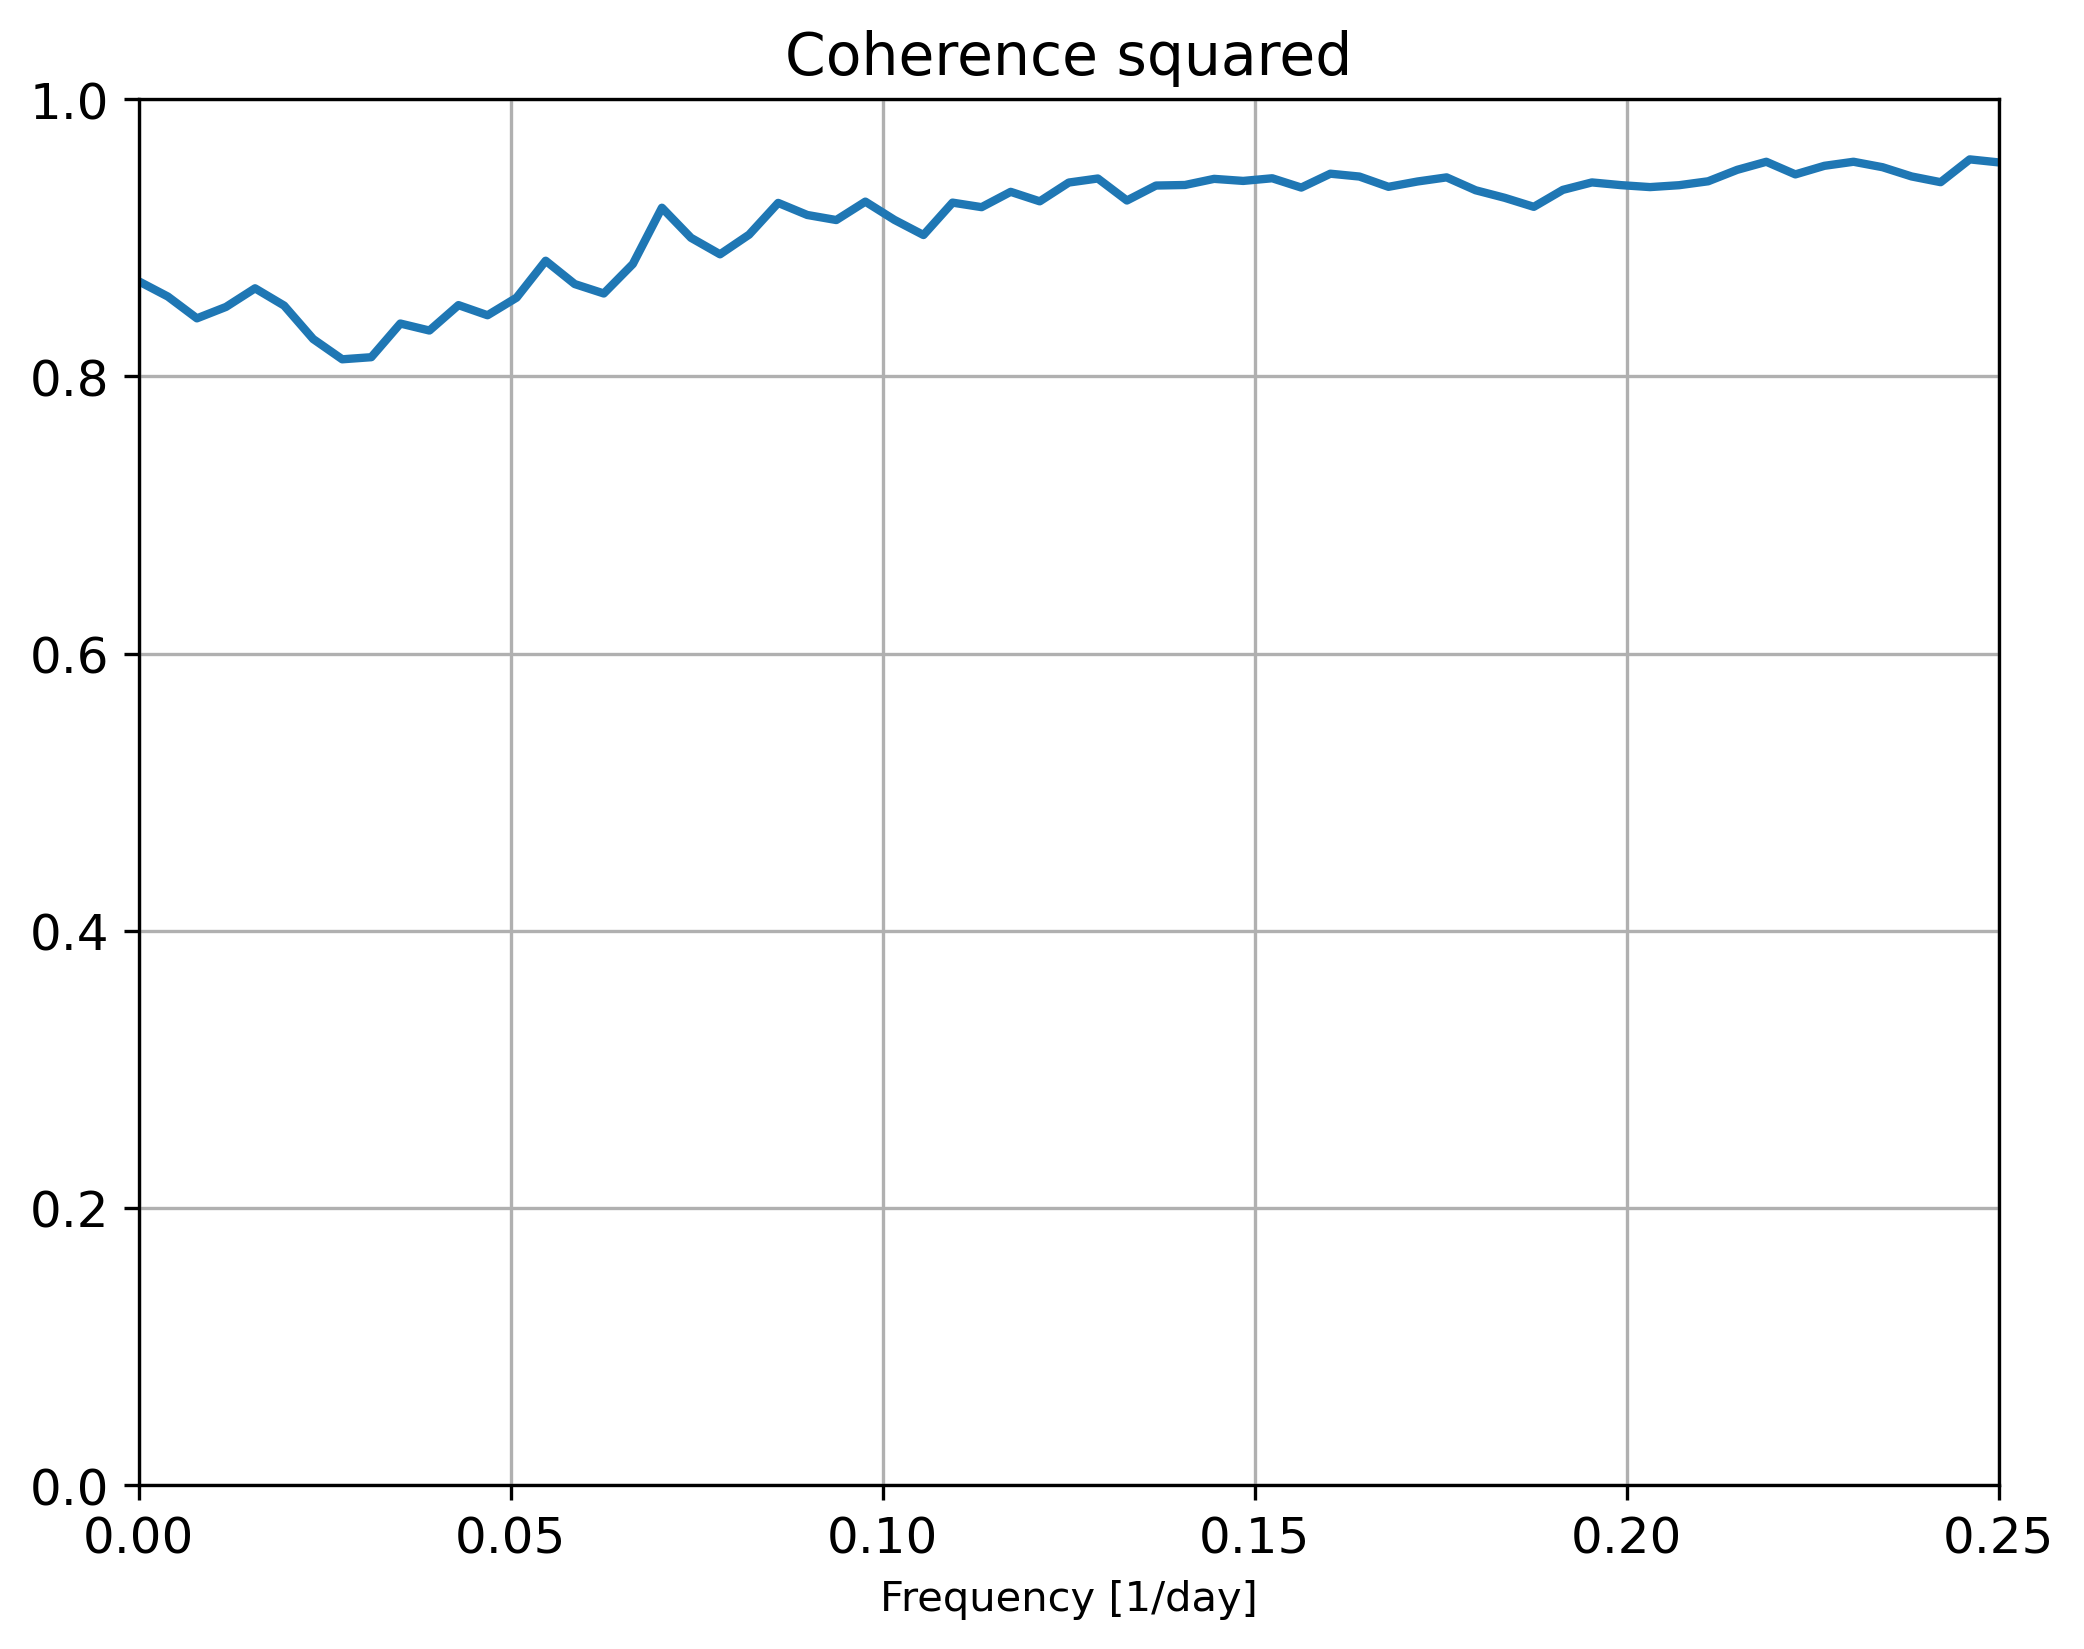

In [297]:
fig, ax = plt.subplots(1, figsize=(8,6), dpi=300)
ax.plot(freqs_1024_shift, np.fft.fftshift(coherence_squared), lw=2)
ax.set_xlim([0,0.25])
ax.set_ylim([0,1])
ax.set_title("Coherence squared", fontsize=14)
ax.set_xlabel("Frequency [1/day]")
plt.grid()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Phase diff

Here, we want to find the angle between Z and M on the the spectrum domain.
if 
   $$ Z  = a + bi $$
   $$ M  = c + di $$
then, 
   $$ S_{zm} = Z^* * M \\
             = (a - bi) + (c + di) 
             = (ac + bd) + (ad - bc)i $$
them the angle would be:
   $$ theta = arctan( {(ad - bc) \over (ac + bd)}) $$
   


In [254]:
# (window_number, day number in each window)
Szm.shape

(130, 1024)

In [255]:
phase_diff = np.atan2(Szm.mean(axis=0).imag,  Szm.mean(axis=0).real) # np.arctan's domain si diff

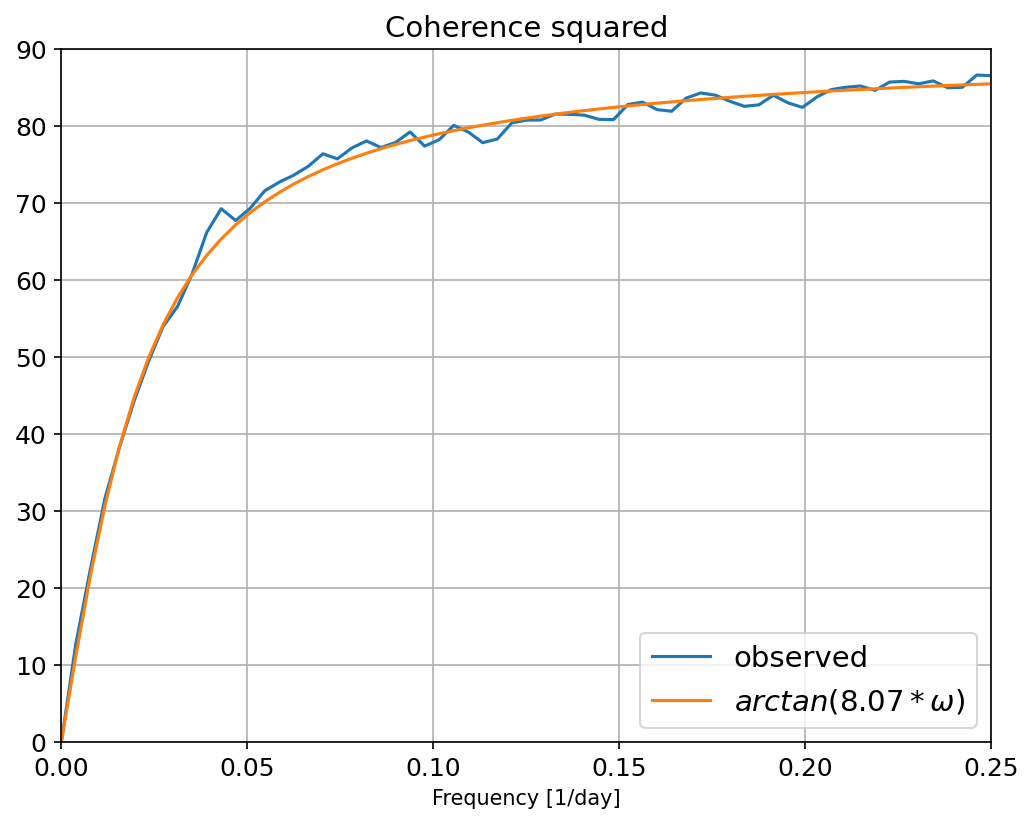

In [304]:
fix, ax = plt.subplots(1, figsize=(8,6), dpi=150.)
ax.plot(freqs_1024_shift, np.rad2deg(np.fft.fftshift(phase_diff)), label="observed")
ax.plot(freqs_1024_shift, np.rad2deg(np.atan(tau * 2 * np.pi * freqs_1024_shift)), label=r"$arctan(8.07 * \omega)$")
ax.legend(fontsize=14)
ax.set_xlim([0,0.25])
ax.set_ylim([0,90])
ax.set_title("Coherence squared", fontsize=14)
ax.set_xlabel("Frequency [1/day]")
plt.grid()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# b value

Appendix C:
b feedback calculation

1. we have z and m time series
2. Divide them into 256-day window, and overlap 128-day
3. Calculate the cross-correlation

In [271]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. Configuration for 6-hourly data
# ==========================================
steps_per_day = 4
chunk_days = 256
overlap_days = 128

chunk_steps = chunk_days * steps_per_day        # 1024 steps
overlap_steps = overlap_days * steps_per_day    # 512 steps
step_size = chunk_steps - overlap_steps         # 512 steps

# Define how many days of lag you want to calculate (LH2001 usually plots +/- 50 days)
max_lag_days = 30
max_lag_steps = max_lag_days * steps_per_day

# Generate the lag array in units of DAYS for plotting
lags_steps = np.arange(-max_lag_steps, max_lag_steps + 1)
lags_days = lags_steps / steps_per_day

# ==========================================
# 2. Calculate Averaged Cross-Correlation
# ==========================================
ccf_sum = np.zeros(len(lags_steps))
valid_chunks = 0

print(f"Dividing {len(z)} steps into {chunk_days}-day chunks with {overlap_days}-day overlaps...")

# Loop through the time series
for i in range(0, len(z) - chunk_steps + 1, step_size):
    z_chunk = z[i : i + chunk_steps]
    m_chunk = m[i : i + chunk_steps]
    
    
    # 1. Calculate standard deviations for normalization
    std_z = np.std(z_chunk)
    std_m = np.std(m_chunk)
            
    # 2. Calculate full cross-covariance for the chunk
    # np.correlate(m, z) means positive lag = z leads m
    cov_full = np.correlate(m_chunk, z_chunk, mode='full') / chunk_steps
    
    # 3. Normalize to get correlation coefficient (-1 to 1)
    corr_full = cov_full / (std_z * std_m)
    
    # 4. Extract only the lags we care about (+/- max_lag_steps)
    center_idx = chunk_steps - 1
    corr_extracted = corr_full[center_idx - max_lag_steps : center_idx + max_lag_steps + 1]
    
    # Add to sum
    ccf_sum += corr_extracted
    valid_chunks += 1

ccf_avg = ccf_sum / valid_chunks

Dividing 67208 steps into 256-day chunks with 128-day overlaps...


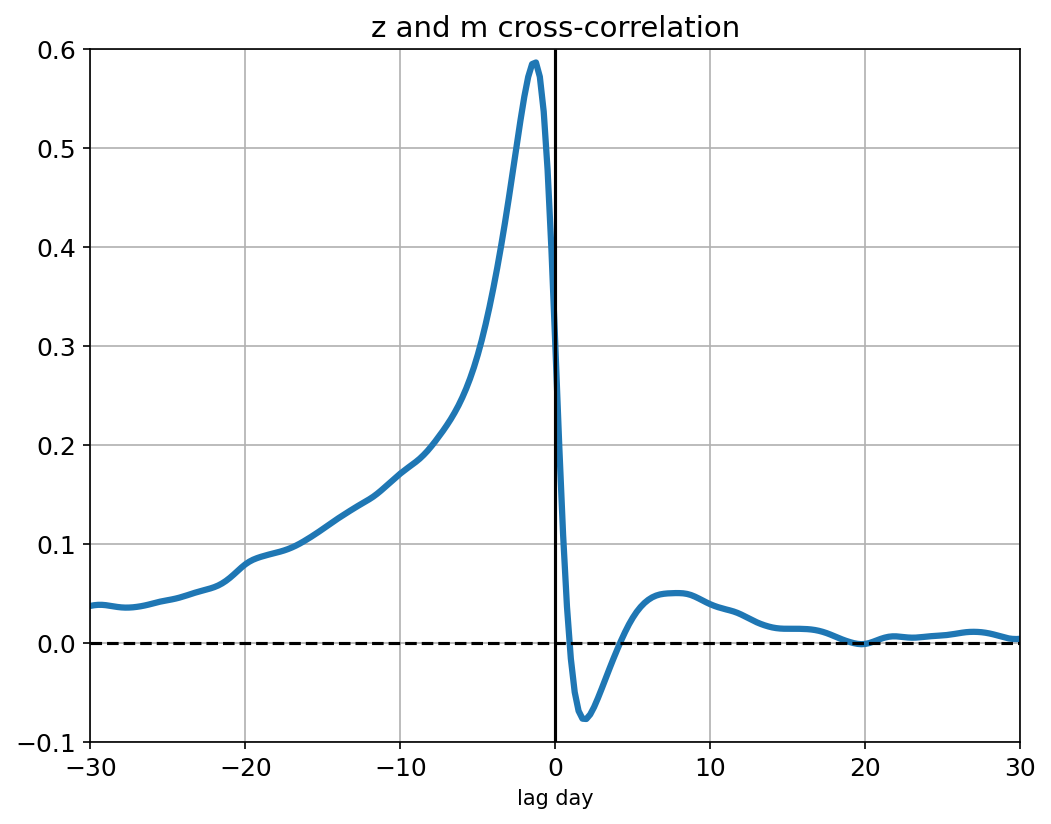

In [310]:
fix, ax = plt.subplots(1, figsize=(8,6), dpi=150.)

ax.plot(lags_days, ccf_avg, lw=3)
ax.hlines(y=0, xmin=-30, xmax=30, color="Black", linestyle="--")
ax.vlines(x=0, ymin=-0.1, ymax=0.6, color="Black", linestyle="-")
ax.set_title("Cross-correlation: z and m")
plt.xlim([-30, 30])
plt.ylim([-0.1, 0.6])

ax.set_title("z and m cross-correlation", fontsize=14)
ax.set_xlabel("lag day")
plt.grid()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

From the cross-correlation between z and m above, at the lag 5-20 day there are some positive feedback,
so the main purpose for calculating the value of b, is to make the "positive feedback" demolished, 
and get the cross-correlation between $\tilde{z}$ and $\tilde{m}$, which is without feedback.

From (C9):
$$ $\tilde{z}$  $$

In [365]:
from scipy.optimize import minimize
b_ini = 0.04
sigma_inv = tau**-1 - b_ini

t = np.linspace(-30*4, 30*4, 241)

def converl(b,  c_zm, tau, t):
    con = np.convolve(c_zm, np.exp(-np.abs(t*0.25)/tau), mode="same")*0.25
    optimized_all = c_zm - b * (1-b*tau/2) * con
    # print(optimized_all.shape)
    return (optimized_all[121 + 7*4 : 121 + 30*4]**2).sum() 
    
# result_con = converl(b_ini, ccf_avg, tau_from_fig2, t)


res = minimize(converl, b_ini, method='nelder-mead', args=(ccf_avg, tau_from_fig2, t),
               options={'xatol': 1e-8, 'disp': True})




Optimization terminated successfully.
         Current function value: 0.003592
         Iterations: 19
         Function evaluations: 38


In [366]:
b = res.x # 6hourly b
print(b)

[0.04297854]


In [335]:
c_zm_without = ccf_avg - b * (1 - b * tau_from_fig2/2) * np.convolve(ccf_avg, np.exp(-np.abs(t*0.25)/tau_from_fig2), mode="same")*0.25

In [336]:
C_zz_0 = np.correlate(z, z, mode="same") / np.correlate(z, z, mode="same").max()
C_mm_0 = np.correlate(m, m, mode="same") / np.correlate(m, m, mode="same").max()


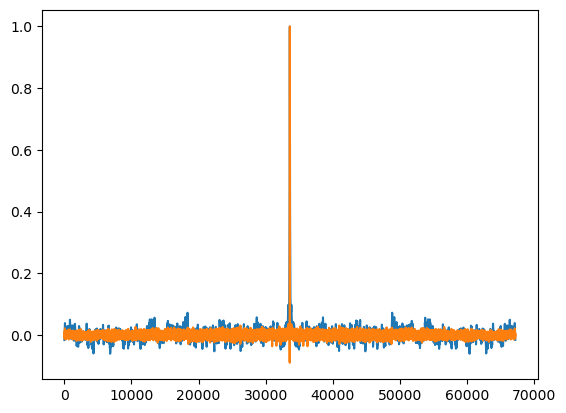

In [337]:
plt.plot(C_zz_0)
plt.plot(C_mm_0)

In [338]:
c_zz_without = C_zz_0[67208//2] - b * (1 - b* tau_from_fig2/2)  * np.convolve(C_zz_0, np.exp(-np.abs(t*0.25)/tau_from_fig2), mode="same")*0.25

In [339]:
c_mm_without = C_mm_0[67208//2] - b * (1 - b* tau_from_fig2/2)  * np.convolve(C_mm_0, np.exp(-np.abs(t*0.25)/tau_from_fig2), mode="same")*0.25

In [340]:
c_zm_without = ((C_zz_0[67208//2] * C_mm_0[67208//2])/ (c_zz_without[67208//2] * c_mm_without[67208//2])) **0.5 * (ccf_avg - b * (1 - b * tau_from_fig2/2) * np.convolve(ccf_avg, np.exp(-np.abs(t*0.25)/tau_from_fig2), mode="same")*0.25)

Text(10, 0.5, 'b=[0.04297854]')

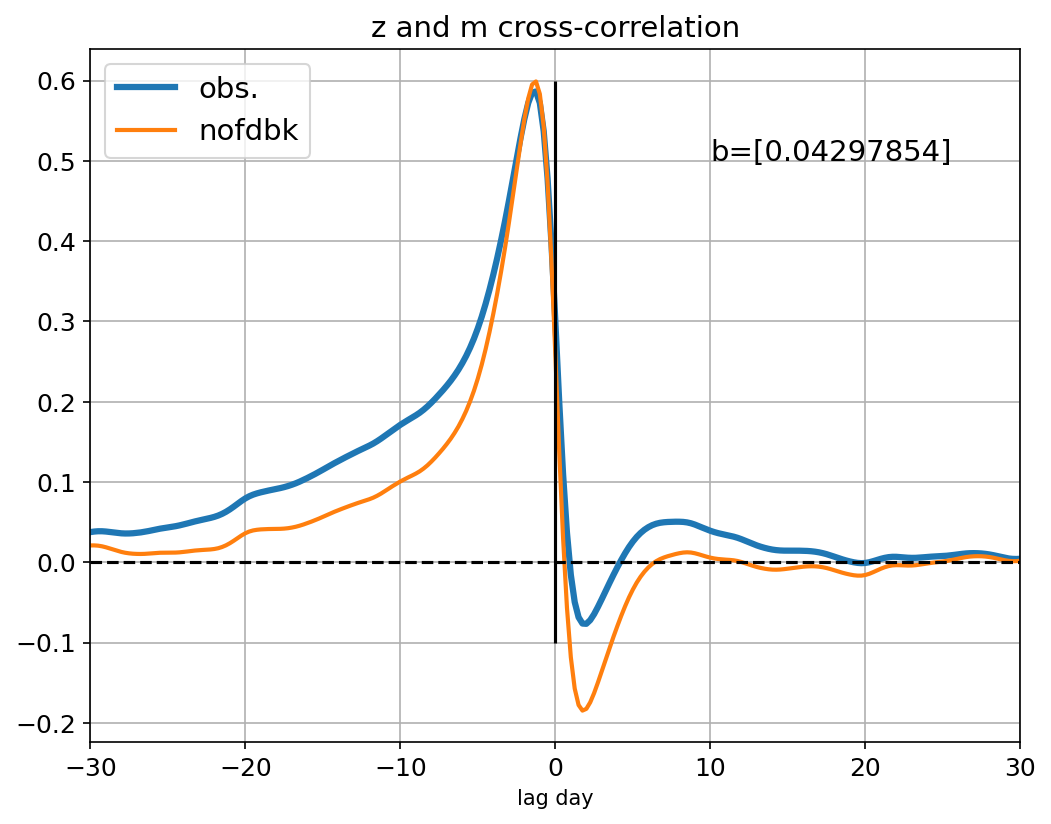

In [367]:
fix, ax = plt.subplots(1, figsize=(8,6), dpi=150.)

ax.plot(lags_days, ccf_avg, lw=3, label = "obs.")
ax.plot(lags_days, c_zm_without, lw=2, label = "nofdbk")

ax.hlines(y=0, xmin=-30, xmax=30, color="Black", linestyle="--")
ax.vlines(x=0, ymin=-0.1, ymax=0.6, color="Black", linestyle="-")
ax.set_title("Cross-correlation: z and m")
plt.xlim([-30, 30])
# plt.ylim([-0.2, 0.63])

ax.set_title("z and m cross-correlation", fontsize=14)
ax.set_xlabel("lag day")
plt.grid()
plt.legend(fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.text(10,0.5, f"b={b%2}", fontsize=14)

In [368]:
z.shape

(67208,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
num_days = len(z) // 4
z_data_daily = z[:num_days * 4].reshape(-1, 4).mean(axis=1)


# Assuming 'z' is your NumPy array of shape (67208,)
chunk_size = 256
overlap = 128
step_size = chunk_size - overlap  # 128 days

# Define the lag range (-30 to +30 days)
max_lag = 30
lags = np.arange(-max_lag, max_lag + 1)

# Generate starting indices for each chunk
starts = np.arange(0, len(z_data_daily) - chunk_size + 1, step_size)

# Array to accumulate the autocorrelations
accumulated_autocorr = np.zeros(len(lags))
valid_chunks = 0

for start in starts:
    # Extract the 256-day chunk
    chunk = z_data_daily[start : start + chunk_size]
    
    # Optional: The paper mentions a Hanning window for spectral analysis. 
    # If you want to strictly match the IFFT of their power spectrum, uncomment the next line:
    # chunk = chunk * np.hanning(chunk_size)
    
    chunk_mean = np.mean(chunk)
    chunk_var = np.var(chunk)
    
    if chunk_var == 0:
        continue
        
    chunk_acorr = []
    
    # Calculate autocorrelation for this specific chunk
    for lag in lags:
        if lag < 0:
            cov = np.mean((chunk[-lag:] - chunk_mean) * (chunk[:lag] - chunk_mean))
        elif lag > 0:
            cov = np.mean((chunk[:-lag] - chunk_mean) * (chunk[lag:] - chunk_mean))
        else:
            cov = chunk_var
            
        chunk_acorr.append(cov / chunk_var)
        
    accumulated_autocorr += np.array(chunk_acorr)
    valid_chunks += 1

# Average the autocorrelation across all valid chunks
mean_autocorr = accumulated_autocorr / valid_chunks

# Plot the result
plt.figure(figsize=(6, 4))
plt.plot(lags, mean_autocorr, color='black', linewidth=2)
# plt.ylim(0, 1.05)
plt.xlim(-max_lag, max_lag)
plt.xlabel('lag (days)')
plt.ylabel('z auto-correlation')
plt.grid(True, linestyle='--')
plt.title('Zonal Index Autocorrelation (256-day chunks, 128-day overlap)')
plt.show()